In [4]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class_comparison"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-svm"
data_set_name = "breast_cancer"

In [6]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

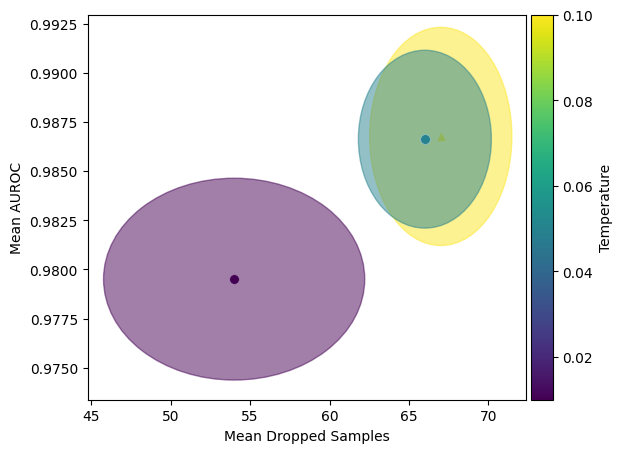

In [25]:
min_x = np.inf
min_y = np.inf
temperatures = dropped_samples.keys().values.astype(float)
cmap = sns.color_palette("viridis", as_cmap=True)
norm = matplotlib.colors.Normalize(vmin=np.min(temperatures), vmax=np.max(temperatures))
fig = plt.figure(figsize=(6,5))
mrs_value = 0.10

for key, dropped_value in dropped_samples.items():
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
    else: 
        marker = "o"
        
    color = cmap(norm(float(key)))
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=50, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=color)
    ax.add_patch(ellipse)
    min_value = np.min(dropped_value.mean() - dropped_value.std())
    min_x =  min_value if min_value < min_x else min_x

    min_value = np.min(auroc_value.mean() - auroc_value.std())
    min_y =  min_value if min_value < min_y else min_y

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cb1 = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                norm=norm,
                                orientation='vertical')
cb1.set_label('Temperature')

_ = ax.set(xlim=min_x - 1, ylim=min_y - 0.001)
_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")